In [14]:
import pandas as pd
import ast

# Load raw data (assuming columns are read as text strings)
df_raw = pd.read_csv("basb_output.csv", header=None)

def clean_mathematica_vector(cell_value):
    """Converts a Mathematica string like '{6, 0, 1}' into a Python list of floats."""
    if pd.isna(cell_value):
        return []
    # Replace Mathematica curly braces with standard Python list brackets
    cleaned_str = str(cell_value).replace('{', '[').replace('}', ']')
    # Safely evaluate the string as a Python list
    return ast.literal_eval(cleaned_str)

# Apply the cleaning function to all 3 columns
df_clean = df_raw.copy()
for col in df_clean.columns:
    df_clean[col] = df_clean[col].apply(clean_mathematica_vector)

# Expand the 3 vector columns into 15 independent numeric columns
all_extracted_columns = []
for col in df_clean.columns:
    # Split the list into separate columns (e.g., col_0_part_0, col_0_part_1...)
    expanded_col = pd.DataFrame(df_clean[col].tolist()).add_prefix(f"col_{col}_")
    all_extracted_columns.append(expanded_col)

# Combine everything into your final Machine Learning ready DataFrame
df_ml = pd.concat(all_extracted_columns, axis=1)

# Verify the new structure
print("New ML DataFrame Shape:", df_ml.shape)
print("\nFirst 3 rows of flattened feature data:")
print(df_ml.head(3))

New ML DataFrame Shape: (37311, 15)

First 3 rows of flattened feature data:
   col_0_0  col_0_1  col_0_2  col_0_3  col_0_4  col_1_0  col_1_1  col_1_2  \
0       27        1        1        0        0        3        3        1   
1       25        1        1        0        0        5        3        1   
2       23        1        1        0        0        7        3        1   

   col_1_3  col_1_4  col_2_0  col_2_1  col_2_2  col_2_3  col_2_4  
0        3        3        0        0        1        0        3  
1        3        3        0        0        1        0        3  
2        3        3        0        0        1        0        3  


In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Initialize the clustering algorithm (looking for 3 natural patterns/phases)
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Fit the model to your 15 columns
df_ml['cluster_label'] = kmeans.fit_predict(df_ml)

# 3. View how many timesteps/agents fell into each behavioral cluster
print("Distribution of simulation states across clusters:")
print(df_ml['cluster_label'].value_counts())


Distribution of simulation states across clusters:
cluster_label
0    12803
1    12369
2    12139
Name: count, dtype: int64


In [16]:
# Calculate the average value of every feature for each individual cluster
cluster_profiles = df_ml.groupby('cluster_label').mean()

# Display the profiles so you can see what makes Cluster 0 different from Cluster 1
print("Average feature values for each cluster phase:")
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all 15 columns on screen
print(cluster_profiles)


Average feature values for each cluster phase:
                col_0_0   col_0_1  col_0_2  col_0_3  col_0_4    col_1_0  \
cluster_label                                                             
0              2.911349  0.445364      1.0      0.0      0.0  14.322268   
1              3.376425  0.454766      1.0      0.0      0.0   7.236883   
2              9.192438  0.498476      1.0      0.0      0.0  11.275723   

                 col_1_1  col_1_2    col_1_3    col_1_4    col_2_0    col_2_1  \
cluster_label                                                                   
0              10.218855      1.0  10.218855  10.218855  12.766383   9.810982   
1               4.335759      1.0   4.335759   4.335759  19.386693  12.172043   
2               4.287833      1.0   4.287833   4.287833   9.531840   5.728396   

                col_2_2    col_2_3  col_2_4  
cluster_label                                
0              1.292431  10.234320      3.0  
1              1.107203   5.21367

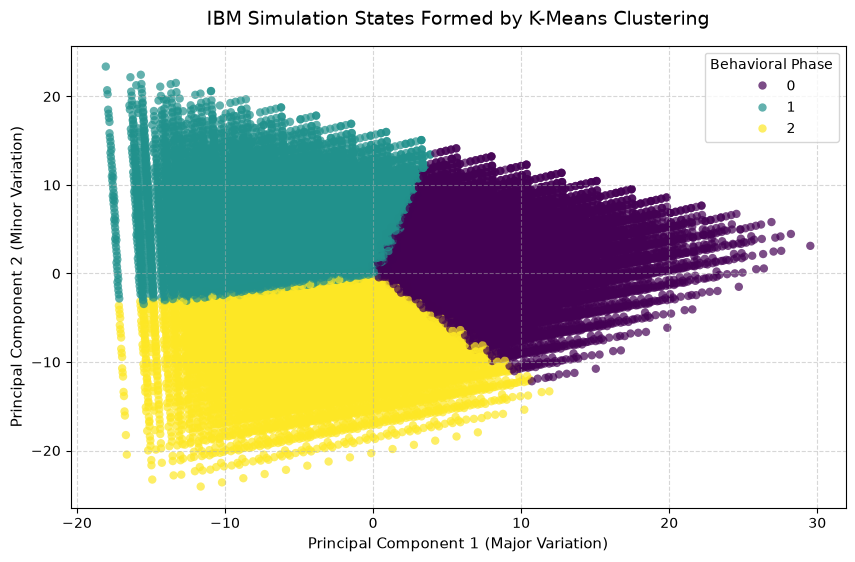

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compress your 15 dimensions down to 2 dimensions for plotting
pca = PCA(n_components=2, random_state=42)
# We exclude the 'cluster_label' column so it doesn't bi-as the geometry
pca_coordinates = pca.fit_transform(df_ml.drop(columns=['cluster_label'], errors='ignore'))

# 2. Put the coordinates into a temporary plotting DataFrame
df_plot = pd.DataFrame(pca_coordinates, columns=['Coordinate_1', 'Coordinate_2'])
df_plot['Cluster'] = df_ml['cluster_label'].values

# 3. Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Coordinate_1', 
    y='Coordinate_2', 
    hue='Cluster', 
    palette='viridis',  # Beautiful color scheme for clusters 0, 1, and 2
    data=df_plot,
    alpha=0.7,          # Makes overlapping dots translucent
    edgecolor='none'
)

# 4. Format the chart text
plt.title('IBM Simulation States Formed by K-Means Clustering', fontsize=14, pad=15)
plt.xlabel('Principal Component 1 (Major Variation)', fontsize=11)
plt.ylabel('Principal Component 2 (Minor Variation)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Behavioral Phase')

# Display the final graph on your screen
plt.show()


In [13]:
# Calculate the average values for every feature per cluster
cluster_profiles = df_ml.groupby('cluster_label').mean()

# Display the summary table
import pandas as pd
pd.set_option('display.max_columns', None)
print("--- MEAN VALUE OF EACH FEATURE PER BEHAVIORAL PHASE ---")
print(cluster_profiles.round(2))


--- MEAN VALUE OF EACH FEATURE PER BEHAVIORAL PHASE ---
               col_0_0  col_0_1  col_0_2  col_0_3  col_0_4  col_1_0  col_1_1  \
cluster_label                                                                  
0                 1.64     0.41      1.0      0.0      0.0     8.89     6.57   
1                 2.02     0.43      1.0      0.0      0.0     4.22     2.70   
2                 5.60     0.50      1.0      0.0      0.0     6.85     2.83   

               col_1_2  col_1_3  col_1_4  col_2_0  col_2_1  col_2_2  col_2_3  \
cluster_label                                                                  
0                  1.0     6.57     6.57     7.47     5.86     1.10     6.56   
1                  1.0     2.70     2.70    11.76     7.67     1.04     3.94   
2                  1.0     2.83     2.83     5.55     3.45     1.01     3.36   

               col_2_4  
cluster_label           
0                  3.0  
1                  3.0  
2                  3.0  
